#1. Setup e caricamento dati

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install imbalanced-learn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF
from imblearn.combine import SMOTETomek
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score


# Caricamento dati
data = pd.read_csv("/content/drive/MyDrive/Cyberbullying-Condivisa/data/raw/cyberbullying_tweets.csv")
X = data['tweet_text']
y = data['cyberbullying_type']

# Train/Test Split Stratificato (questo evita data leakage)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y
)

custom_stopwords = set(ENGLISH_STOP_WORDS)


# 2. Analisi esplorativa visiva



--- ANALISI ESPLORATIVA: LE PAROLE PIÙ FREQUENTI ---


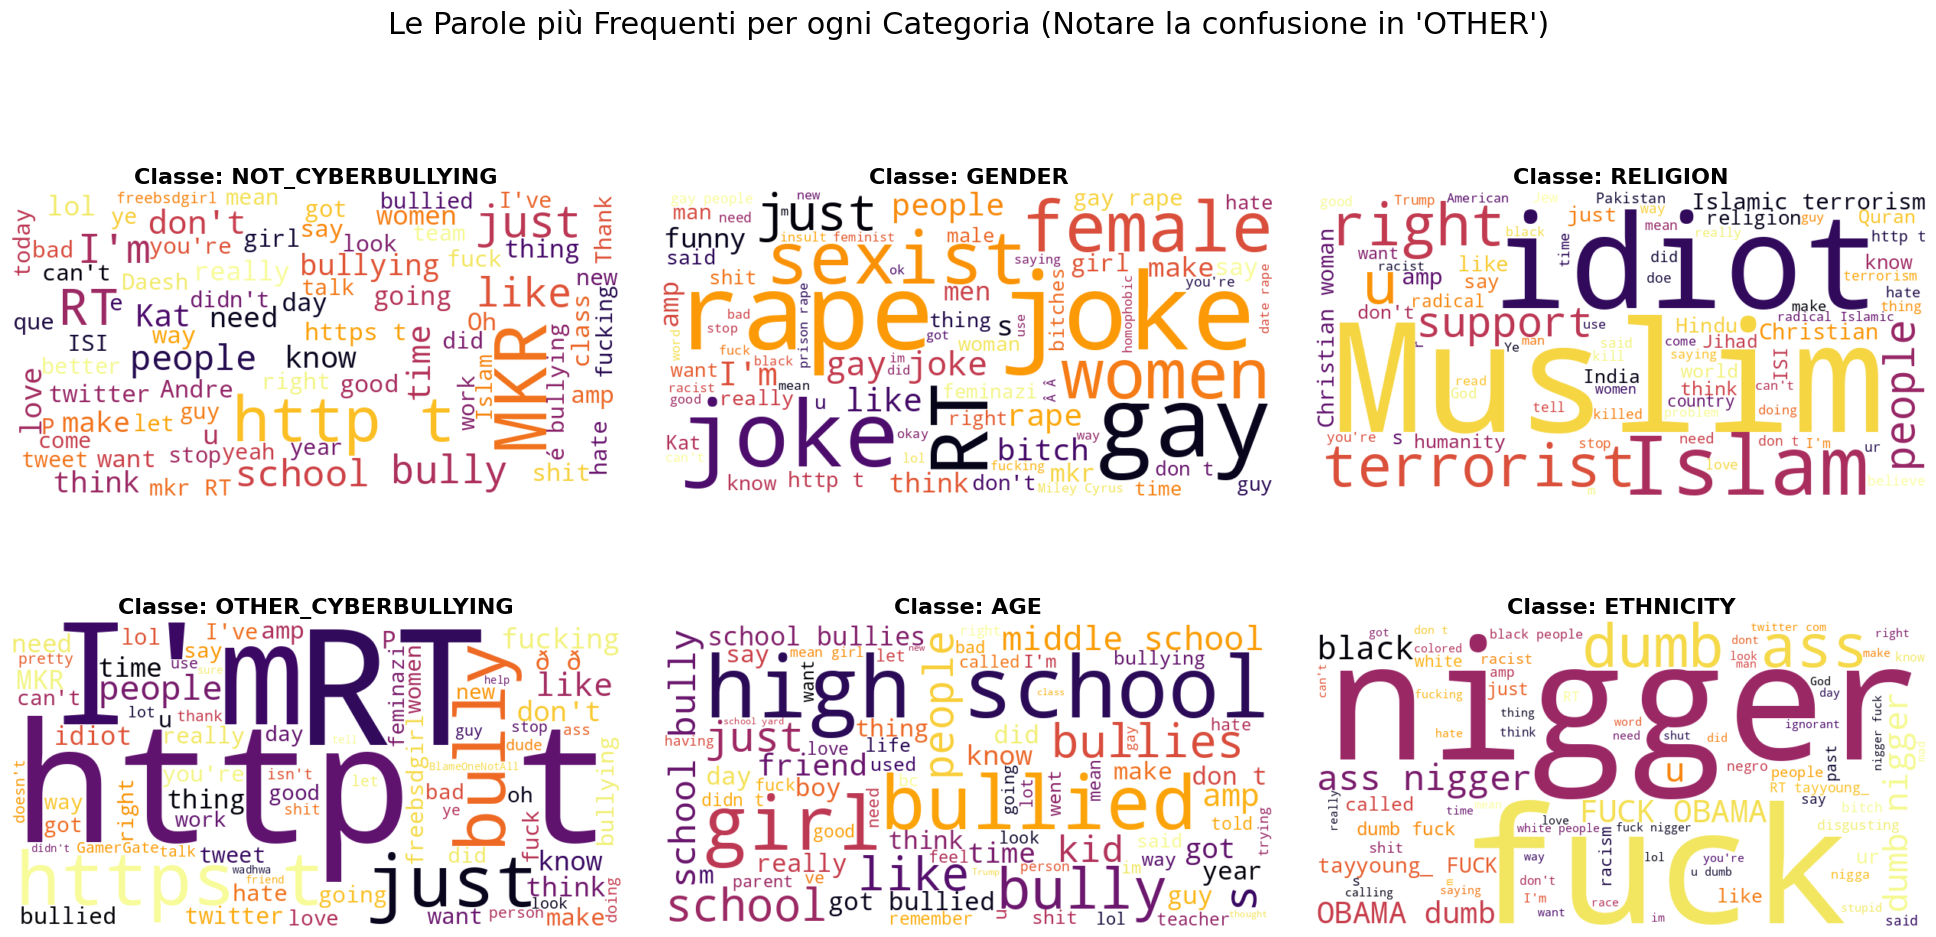

In [ ]:
print("\n--- ANALISI ESPLORATIVA: LE PAROLE PIÙ FREQUENTI ---")

classi = data['cyberbullying_type'].unique()
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, classe in enumerate(classi):
    # Uniamo tutti i testi della classe corrente
    testo_classe = " ".join(tweet for tweet in data[data['cyberbullying_type'] == classe]['tweet_text'])

    # Generiamo la WordCloud
    wordcloud = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=custom_stopwords, # Filtra via il "rumore" visivo
        colormap='inferno',
        max_words=75
    ).generate(testo_classe)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"Classe: {classe.upper()}", fontsize=16, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout(pad=3.0)
plt.suptitle("Le Parole più Frequenti per ogni Categoria (Notare la confusione in 'OTHER')", fontsize=22, y=1.05)
plt.show()

#2.5 Analisi esplorativa NMF


--- ANALISI ESPLORATIVA: TOPIC IN 'OTHER_CYBERBULLYING' ---


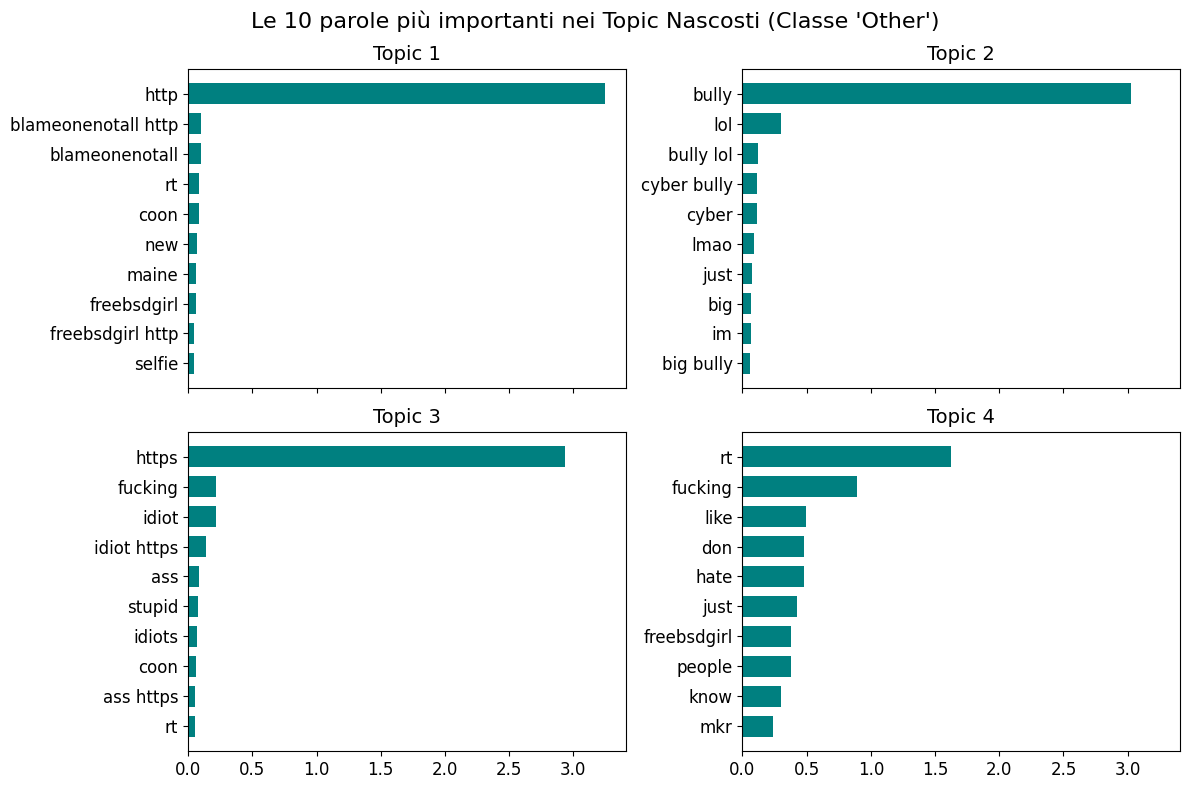

In [ ]:
print("\n--- ANALISI ESPLORATIVA: TOPIC IN 'OTHER_CYBERBULLYING' ---")

# 1. Selezioniamo solo i tweet della classe 'other' per indagare la sua ambiguità
tweet_other = data[data['cyberbullying_type'] == 'other_cyberbullying']['tweet_text']

# 2. Creiamo un TF-IDF temporaneo standard solo per questa analisi NMF
tfidf_other = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english', ngram_range=(1, 2))
X_other_tfidf = tfidf_other.fit_transform(tweet_other)

# 3. Applichiamo la NMF per estrarre 4 topic nascosti (matrice delle basi W)
nmf_other = NMF(n_components=4, random_state=42, init='nndsvd')
nmf_other.fit(X_other_tfidf)
feature_names_nmf = tfidf_other.get_feature_names_out()

# 4. Generiamo il grafico a barre per mostrare cosa ha scoperto l'NMF
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for topic_idx, topic in enumerate(nmf_other.components_):
    top_features_ind = topic.argsort()[:-10 - 1:-1]
    top_features = [feature_names_nmf[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    ax.barh(top_features, weights, height=0.7, color='teal')
    ax.set_title(f'Topic {topic_idx +1}', fontdict={'fontsize': 14})
    ax.invert_yaxis()
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.suptitle("Le 10 parole più importanti nei Topic Nascosti (Classe 'Other')", fontsize=16)
plt.tight_layout()
plt.show()

#3. Pre-processing e Feature Extraction (TF-IDf + Bigrammi)

In [ ]:
print("\n--- ESTRAZIONE FEATURE (TF-IDF CON UNIGRAMMI E BIGRAMMI) ---")

# Definizione Stopwords estese
custom_stopwords = set(ENGLISH_STOP_WORDS).union(
    {'http', 'https', 'rt', 'co', 'amp', 'u', 'just', 'like', "i'm", 'people', 'dont', 'make', 't'}
)

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,          # Limitiamo a 10.000
    max_df=0.95,
    min_df=2,
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2)           # Estraiamo parole singole e coppie di parole
)

X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)


--- ESTRAZIONE FEATURE (TF-IDF CON UNIGRAMMI E BIGRAMMI) ---


#4. SMOTETomek

In [ ]:
print("\n--- APPLICAZIONE SMOTETOMEK (RIMOZIONE TWEET AMBIGUI) ---")
print(f"Campioni PRIMA di SMOTETomek: {X_train.shape[0]}")

smote_tomek = SMOTETomek(random_state=67)
X_train_hybrid, y_train_hybrid = smote_tomek.fit_resample(X_train, y_train)

print(f"Campioni DOPO i Tomek Links: {X_train_hybrid.shape[0]}")
print(f"Nota: La differenza numerica rappresenta i campioni 'rumorosi' o sovrapposti eliminati ai confini delle classi ({X_train.shape[0]-X_train_hybrid.shape[0]}).")


--- APPLICAZIONE SMOTETOMEK (RIMOZIONE TWEET AMBIGUI) ---
Campioni PRIMA di SMOTETomek: 38153
Campioni DOPO i Tomek Links: 37250
Nota: La differenza numerica rappresenta i campioni 'rumorosi' o sovrapposti eliminati ai confini delle classi (903).


#5. Addestramento Modelli - KNN e Random Forest

In [ ]:
#Addestramento KNN euclidea
print("\n--- ADDESTRAMENTO MODELLI ---")
knn_clf_euc = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn_clf_euc.fit(X_train_hybrid, y_train_hybrid)
y_pred_knn_euc = knn_clf_euc.predict(X_test)

#Addestramento KNN coseno
print("\n--- ADDESTRAMENTO MODELLI ---")
knn_clf_cos = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='cosine')
knn_clf_cos.fit(X_train_hybrid, y_train_hybrid)
y_pred_knn_cos = knn_clf_cos.predict(X_test)


#Albero singolo depht 10
print("--- ADDESTRAMENTO ALBERO DI DECISIONE CON DEPTH 10---")

# Inizializziamo il classificatore limitando la profondità per evitare overfitting
dt_clf_10 = DecisionTreeClassifier(max_depth=10, random_state=67)

# Addestriamo il modello
dt_clf_10.fit(X_train, y_train)

# Effettuiamo le predizioni sul test set
y_pred_dt_10 = dt_clf_10.predict(X_test)

#Calcolo depht migliore
depths = [1, 2, 3, 5, 10, 15, None]
for d in depths:
    # Inizializziamo l'albero usando l'Indice di Gini come criterio di split
    clf = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=67)
    clf.fit(X_train, y_train)

    # Valutiamo l'accuracy sia sul train che sul test per scovare l'overfitting
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    print(f"max_depth={d} -> train={acc_train:.4f}, test={acc_test:.4f}")

#Albero con none
print("--- ADDESTRAMENTO ALBERO DI DECISIONE CON DEPTH NONE---")

dt_clf_none = DecisionTreeClassifier(max_depth=None, random_state=67)

# Addestriamo il modello
dt_clf_none.fit(X_train, y_train)

# Effettuiamo le predizioni sul test set
y_pred_dt_none = dt_clf_none.predict(X_test)


#Addestramento Random Forest con 5 alberi
print("--- ADDESTRAMENTO RANDOM FOREST (5 alberi)---")
rf_clf_5 = RandomForestClassifier(n_estimators=5, criterion='gini', random_state=67, n_jobs=-1)
rf_clf_5.fit(X_train_hybrid, y_train_hybrid)
y_pred_rf_5 = rf_clf_5.predict(X_test)

#Addestramento Random Forest con 200 alberi
print("--- ADDESTRAMENTO RANDOM FOREST (200 alberi)---")
rf_clf_200 = RandomForestClassifier(n_estimators=200, criterion='gini', random_state=67, n_jobs=-1)
rf_clf_200.fit(X_train_hybrid, y_train_hybrid)
y_pred_rf_200 = rf_clf_200.predict(X_test)



--- ADDESTRAMENTO MODELLI ---

--- ADDESTRAMENTO MODELLI ---
--- ADDESTRAMENTO ALBERO DI DECISIONE CON DEPTH 10---
max_depth=1 -> train=0.3209, test=0.3212
max_depth=2 -> train=0.4228, test=0.4252
max_depth=3 -> train=0.5044, test=0.5053
max_depth=5 -> train=0.5849, test=0.5891
max_depth=10 -> train=0.6930, test=0.6897
max_depth=15 -> train=0.7658, test=0.7570
max_depth=None -> train=0.9635, test=0.8032
--- ADDESTRAMENTO ALBERO DI DECISIONE CON DEPTH NONE---
--- ADDESTRAMENTO RANDOM FOREST (5 alberi)---
--- ADDESTRAMENTO RANDOM FOREST (200 alberi)---


#6. Valutazione finale - Matrici e Metriche

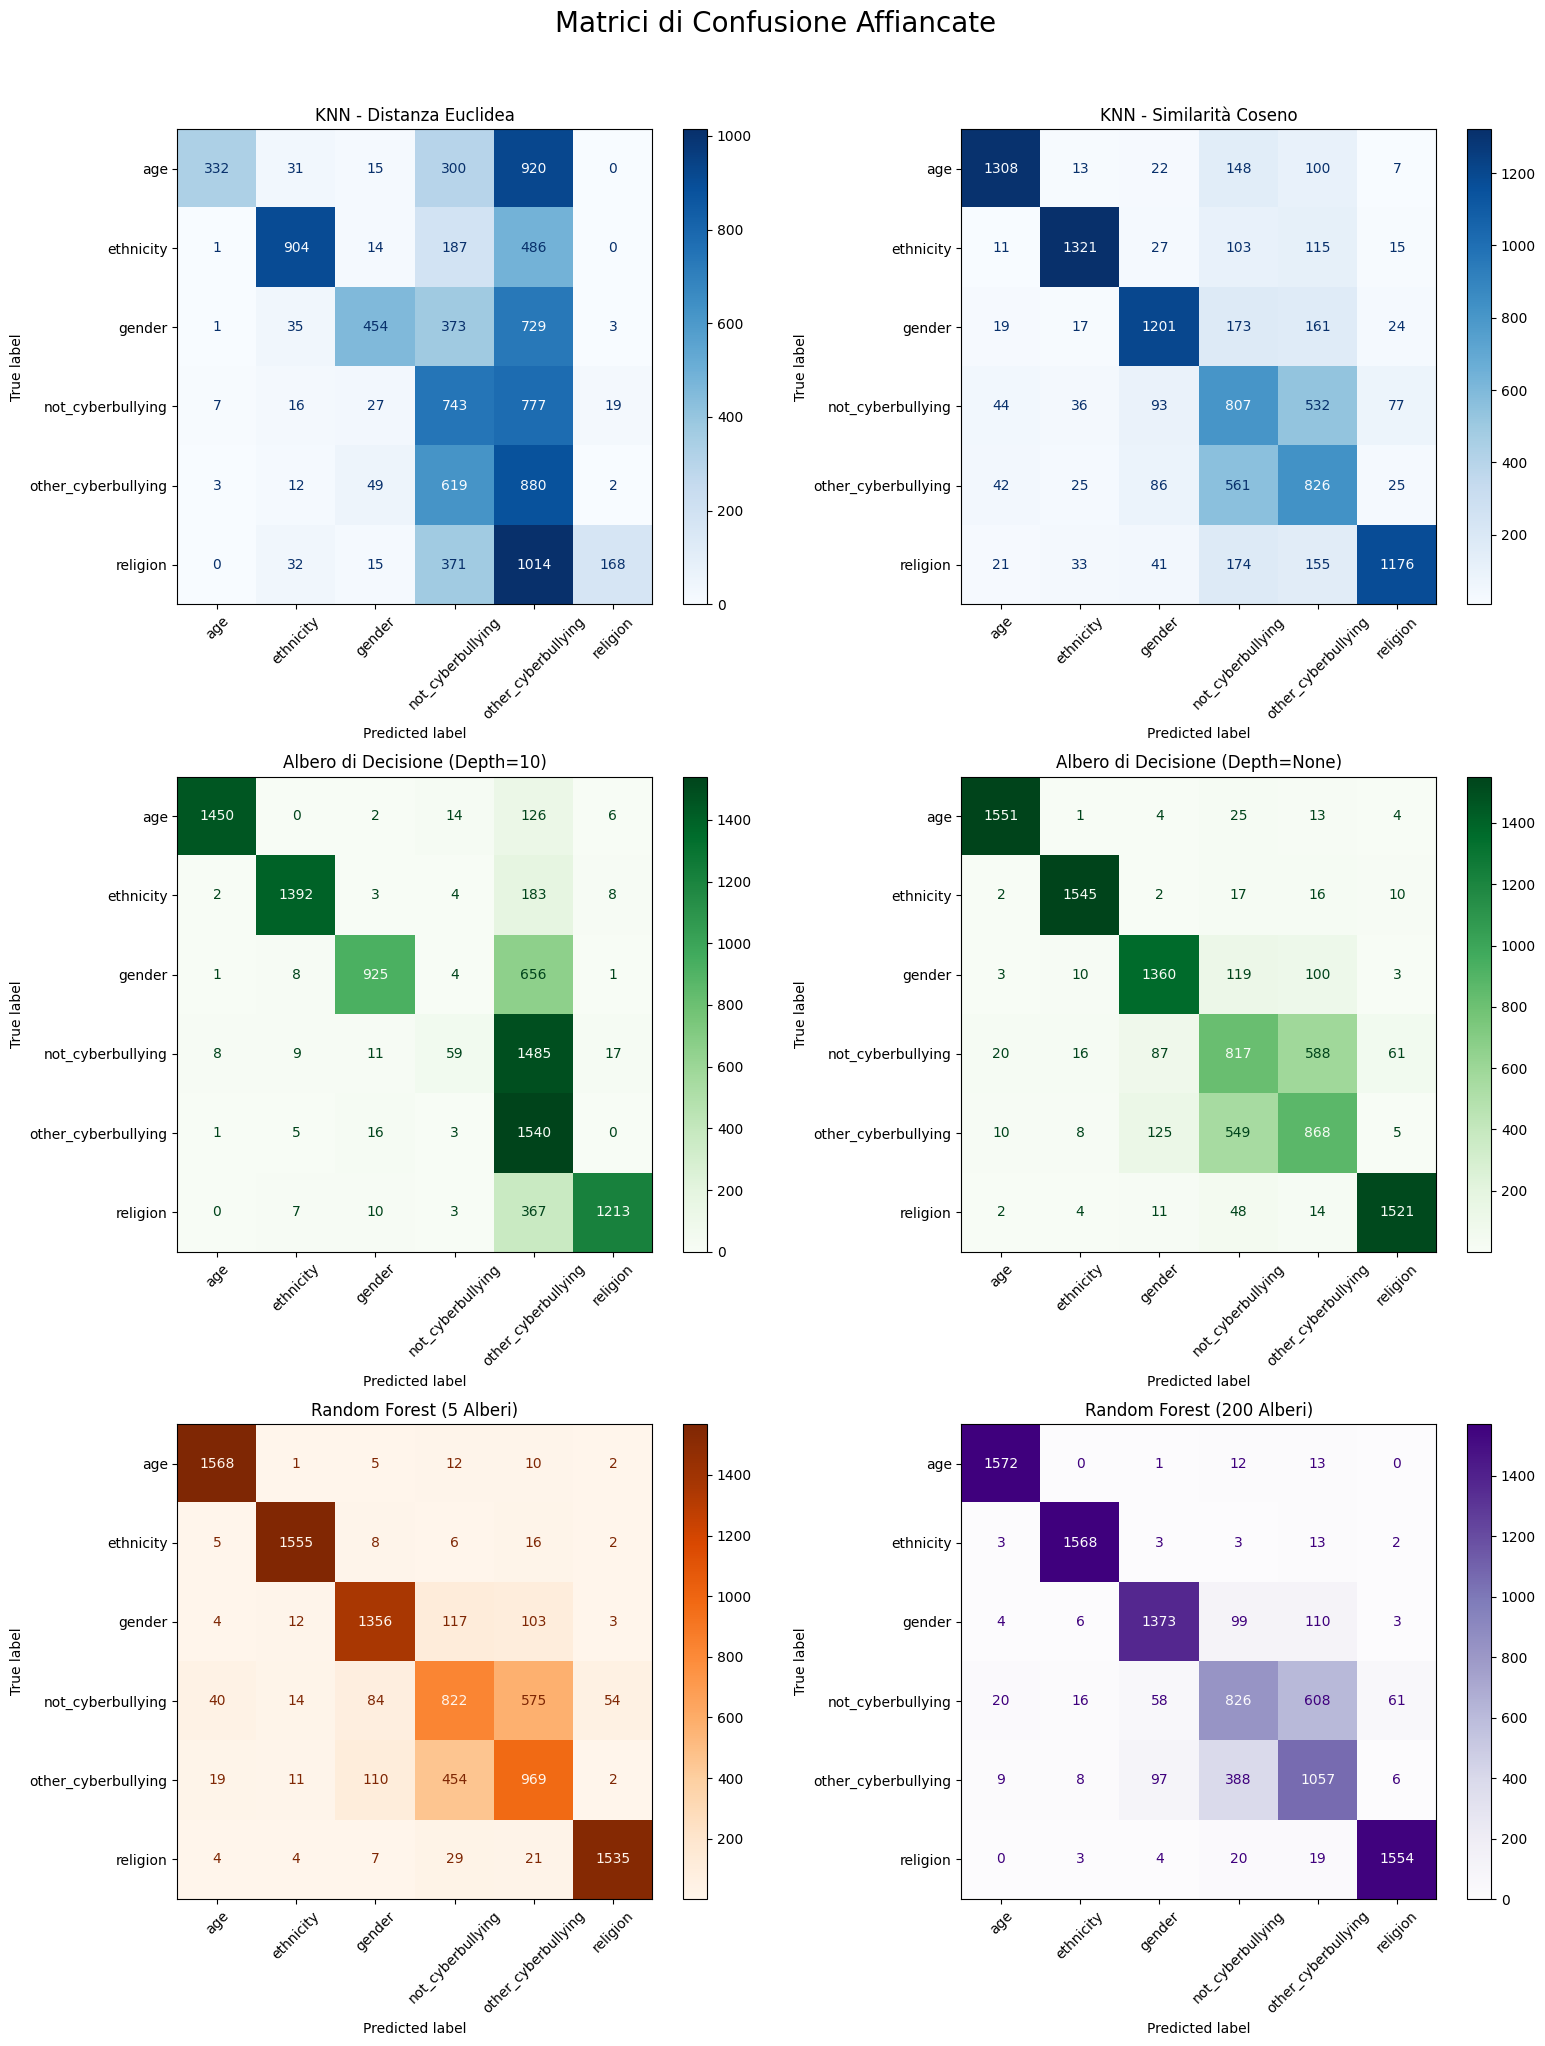

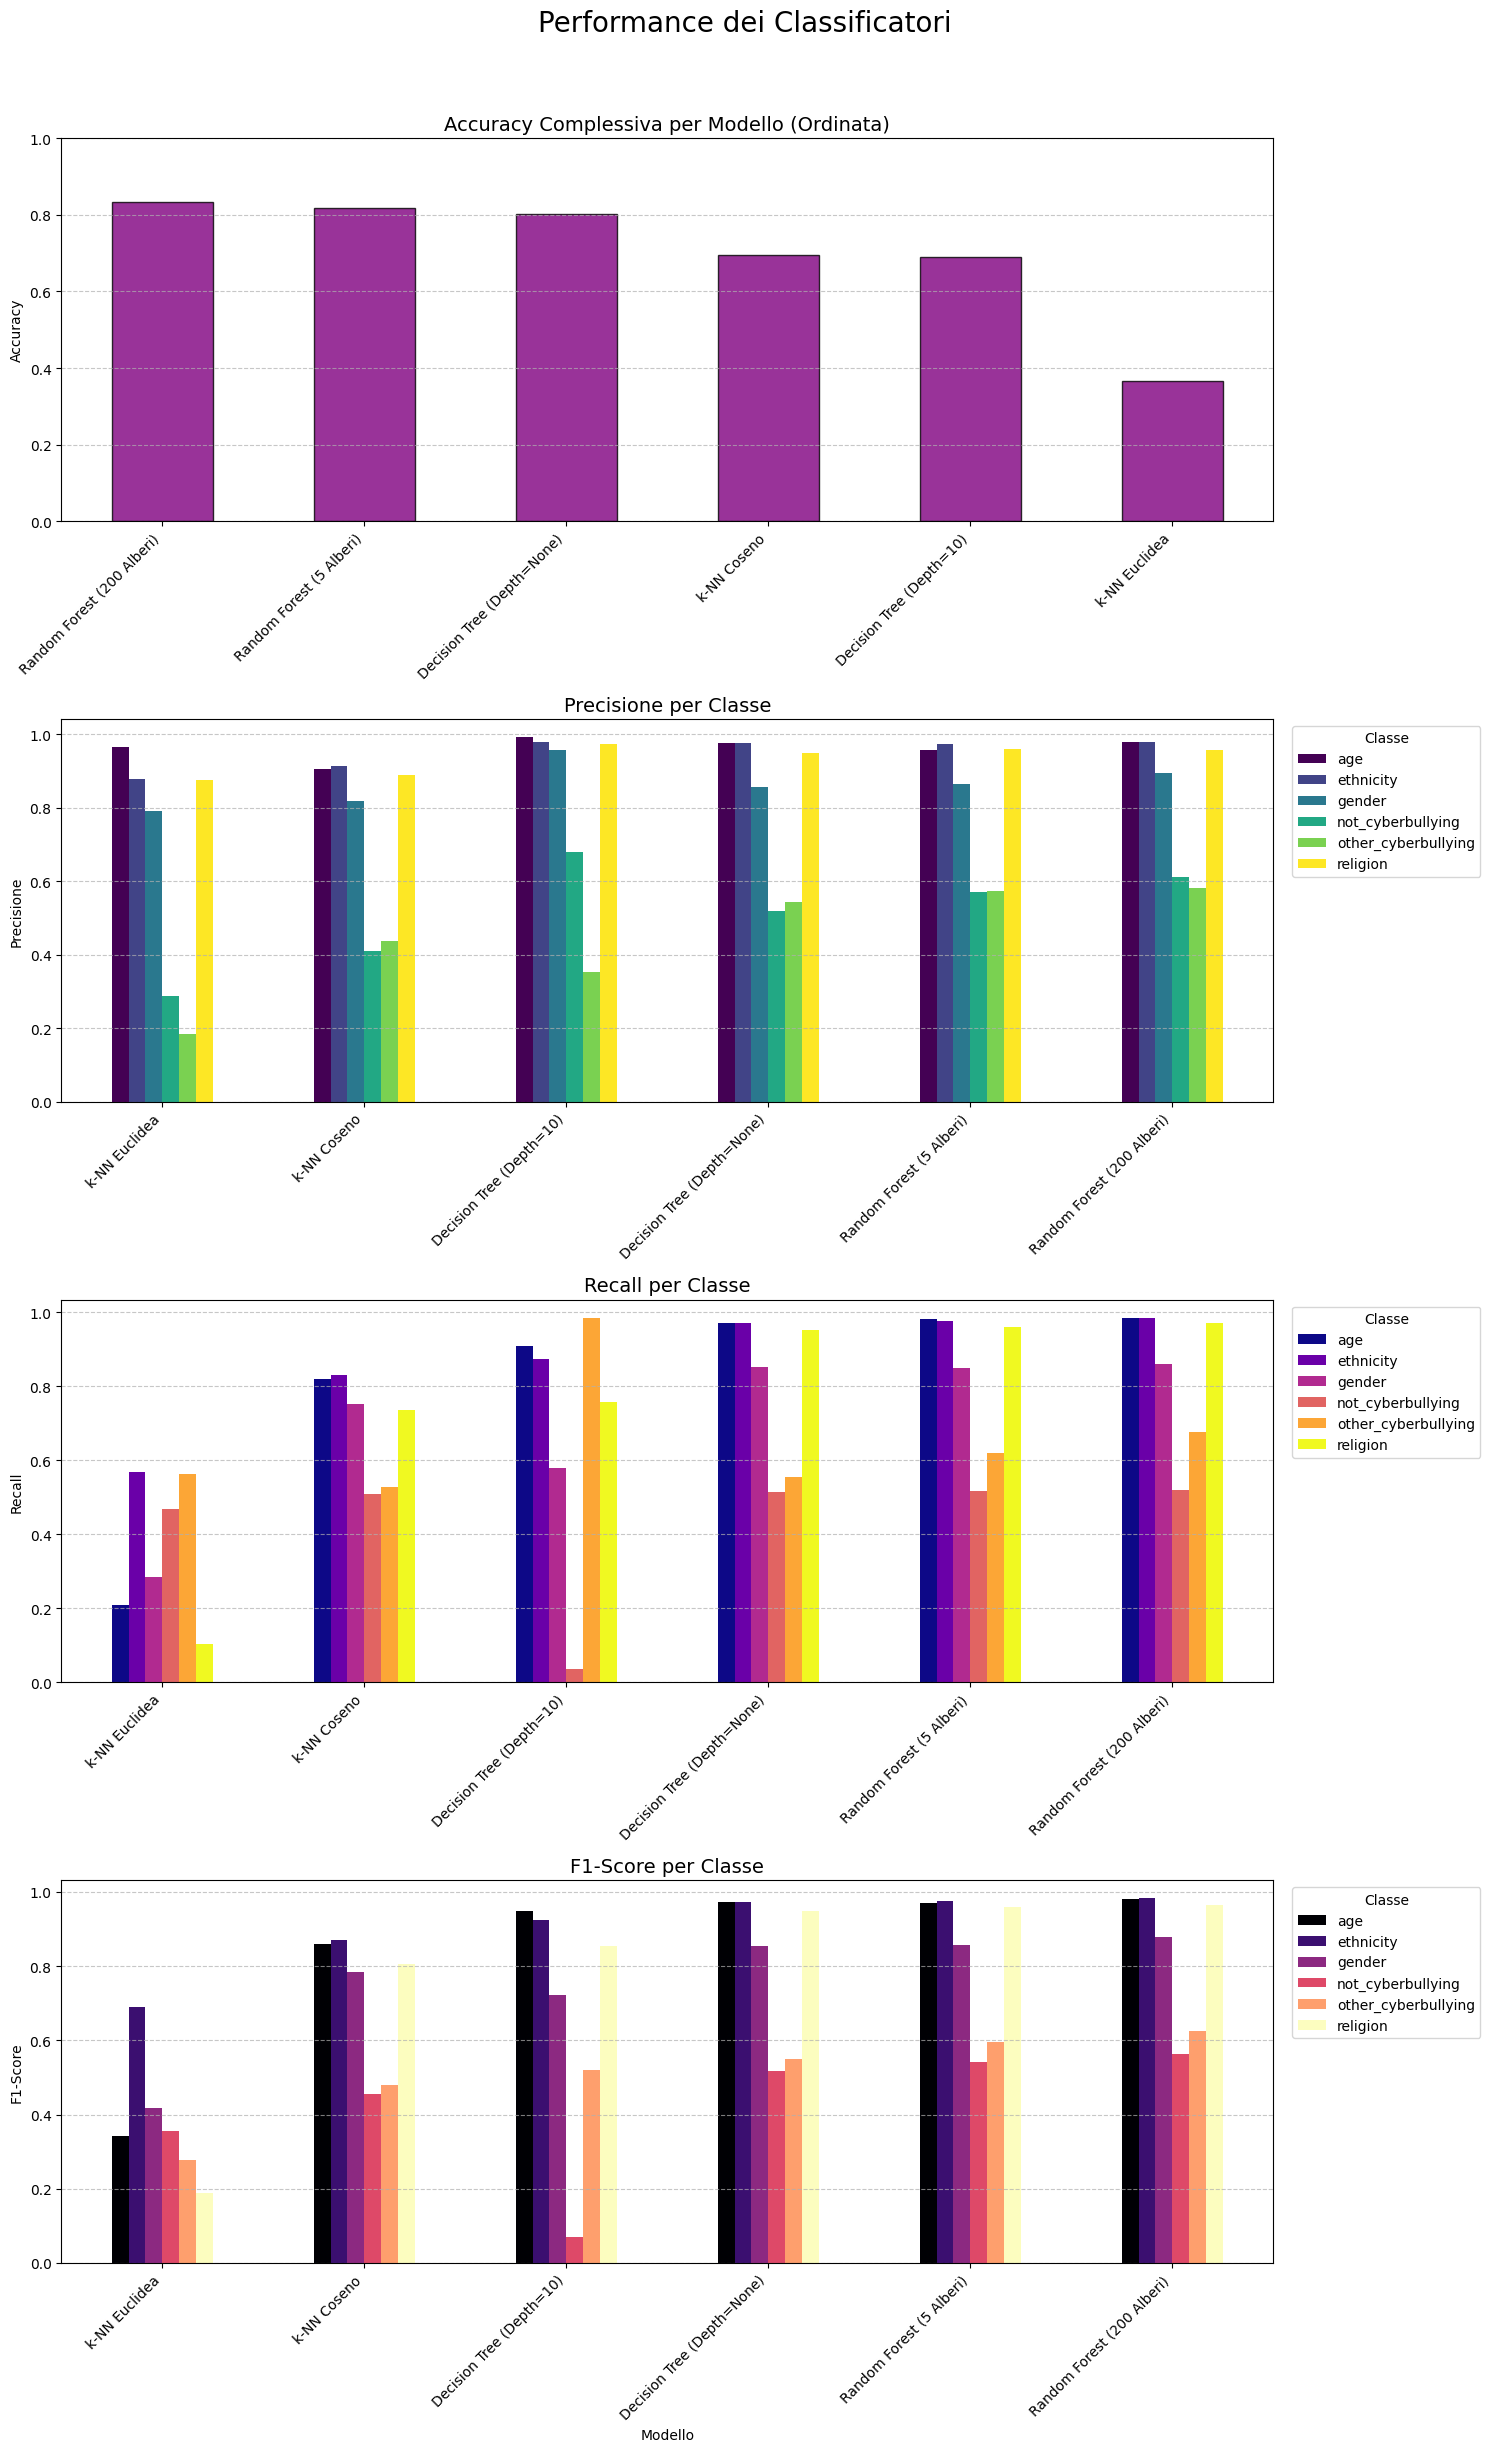

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

# --- PARTE 1: Matrici di Confusione Affiancate ---
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
fig.suptitle('Matrici di Confusione Affiancate', fontsize=20, y=1.02)

# --- CONFRONTO 1: KNN METRICHE ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_euc, cmap='Blues', ax=axes[0, 0], xticks_rotation=45)
axes[0, 0].set_title("KNN - Distanza Euclidea")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_cos, cmap='Blues', ax=axes[0, 1], xticks_rotation=45)
axes[0, 1].set_title("KNN - Similarità Coseno")

# --- CONFRONTO 2: DECISION TREE DEPTH ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_10, cmap='Greens', ax=axes[1, 0], xticks_rotation=45)
axes[1, 0].set_title("Albero di Decisione (Depth=10)")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_none, cmap='Greens', ax=axes[1, 1], xticks_rotation=45)
axes[1, 1].set_title("Albero di Decisione (Depth=None)")

# --- CONFRONTO 3: RANDOM FOREST ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_5, cmap='Oranges', ax=axes[2, 0], xticks_rotation=45)
axes[2, 0].set_title("Random Forest (5 Alberi)")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_200, cmap='Purples', ax=axes[2, 1], xticks_rotation=45)
axes[2, 1].set_title("Random Forest (200 Alberi)")

plt.tight_layout()
plt.show()

# ==============================================================================
# --- PARTE 2: VISUALIZZAZIONE GRAFICA DEI REPORT DI CLASSIFICAZIONE ---
# ==============================================================================

# Modelli e predizioni corrispondenti
models = {
    'k-NN Euclidea': y_pred_knn_euc,
    'k-NN Coseno': y_pred_knn_cos,
    'Decision Tree (Depth=10)': y_pred_dt_10,
    'Decision Tree (Depth=None)': y_pred_dt_none,
    'Random Forest (5 Alberi)': y_pred_rf_5,
    'Random Forest (200 Alberi)': y_pred_rf_200
}

# Dizionari per salvare i risultati
accuracy_scores = {}
precision_scores = {}
recall_scores = {}
f1_scores = {}

# Estrae i report per ogni modello
for model_name, y_pred in models.items():
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Estrae e salva l'Accuracy complessiva
    accuracy_scores[model_name] = accuracy_score(y_test, y_pred)

    # Estrae i punteggi per ogni classe
    precision_scores[model_name] = {k: v['precision'] for k, v in report.items() if k not in ['accuracy', 'macro avg', 'weighted avg']}
    recall_scores[model_name] = {k: v['recall'] for k, v in report.items() if k not in ['accuracy', 'macro avg', 'weighted avg']}
    f1_scores[model_name] = {k: v['f1-score'] for k, v in report.items() if k not in ['accuracy', 'macro avg', 'weighted avg']}

# Converti in DataFrame/Series
df_precision = pd.DataFrame(precision_scores).T
df_recall = pd.DataFrame(recall_scores).T
df_f1 = pd.DataFrame(f1_scores).T

accuracy_series_sorted = pd.Series(accuracy_scores).sort_values(ascending=False)

# --- Plot dei risultati ---
fig, axes = plt.subplots(4, 1, figsize=(15, 24)) # 4 righe, 1 colonna
fig.suptitle('Performance dei Classificatori', fontsize=20, y=1.02)

# 1. ACCURACY (Singola barra per modello, ordinata)
accuracy_series_sorted.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black', alpha=0.8)
axes[0].set_title('Accuracy Complessiva per Modello (Ordinata)', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
for tick in axes[0].get_xticklabels():
    tick.set_ha('right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. PRECISION (Dettaglio per classe)
df_precision.plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Precisione per Classe', fontsize=14)
axes[1].set_ylabel('Precisione')
axes[1].tick_params(axis='x', rotation=45)
for tick in axes[1].get_xticklabels():
    tick.set_ha('right')
axes[1].legend(title='Classe', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. RECALL (Dettaglio per classe)
df_recall.plot(kind='bar', ax=axes[2], colormap='plasma')
axes[2].set_title('Recall per Classe', fontsize=14)
axes[2].set_ylabel('Recall')
axes[2].tick_params(axis='x', rotation=45)
for tick in axes[2].get_xticklabels():
    tick.set_ha('right')
axes[2].legend(title='Classe', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# 4. F1-SCORE (Dettaglio per classe)
df_f1.plot(kind='bar', ax=axes[3], colormap='magma')
axes[3].set_title('F1-Score per Classe', fontsize=14)
axes[3].set_ylabel('F1-Score')
axes[3].set_xlabel('Modello')
axes[3].tick_params(axis='x', rotation=45)
for tick in axes[3].get_xticklabels():
    tick.set_ha('right')
axes[3].legend(title='Classe', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[3].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Metriche complesse per modello

In [ ]:
print("\n--- METRICHE COMPLESSIVE PER MODELLO ---")

for model_name, y_pred in models.items():
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    macro_precision = report['macro avg']['precision']
    macro_recall = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']
    accuracy = accuracy_scores[model_name]

    print(f"\n{model_name}")
    print(f"\tAccuracy:\t\t{accuracy:.4f}")
    print(f"\tPrecision:\t\t{macro_precision:.4f}")
    print(f"\tRecall:\t\t\t{macro_recall:.4f}")
    print(f"\tF1-Score:\t\t{macro_f1:.4f}")


--- METRICHE COMPLESSIVE PER MODELLO ---

k-NN Euclidea
	Accuracy:		0.3649
	Precision:		0.6631
	Recall:			0.3659
	F1-Score:		0.3782

k-NN Coseno
	Accuracy:		0.6960
	Precision:		0.7287
	Recall:			0.6953
	F1-Score:		0.7083

Decision Tree (Depth=10)
	Accuracy:		0.6897
	Precision:		0.8223
	Recall:			0.6902
	F1-Score:		0.6728

Decision Tree (Depth=None)
	Accuracy:		0.8032
	Precision:		0.8030
	Recall:			0.8022
	F1-Score:		0.8026

Random Forest (5 Alberi)
	Accuracy:		0.8182
	Precision:		0.8162
	Recall:			0.8173
	F1-Score:		0.8163

Random Forest (200 Alberi)
	Accuracy:		0.8334
	Precision:		0.8334
	Recall:			0.8327
	F1-Score:		0.8317
